In [ ]:
import h5py
import numpy as np
import matplotlib.pyplot as plt
from scipy.special import sph_harm

fname = "SL_all_p01/modes.h5"

def lm_of_n(n):
    l = int(np.floor(np.sqrt(n)))
    m = n - l*l - l
    return l, m

# Parámetros de imagen
Lbox = 5000.0
Nxy  = 600   # sube a 500 solo cuando ya estés seguro de que se ve bien

# Malla xy
x = np.linspace(-Lbox, Lbox, Nxy, dtype=np.float32)
y = np.linspace(-Lbox, Lbox, Nxy, dtype=np.float32)

X, Y = np.meshgrid(x, y, indexing="xy")
R = np.sqrt(X*X + Y*Y)
Phi = np.arctan2(Y, X)

Rflat = R.ravel()
Phiflat = Phi.ravel()

# Cargar datos una sola vez
modes = []

with h5py.File(fname, "r") as f:
    groups = sorted(
        [g for g in f.keys() if g.startswith("mode_")],
        key=lambda s: int(s.split("_")[1])
    )

    g0 = groups[0]

    if "r" in f:
        r_data = f["r"][:].astype(np.float64)
    else:
        r_data = f[g0]["vr"][:, 0].astype(np.float64)

    t_data = f[g0]["t"][:]

    valid = (Rflat >= r_data.min()) & (Rflat <= r_data.max())
    Rv = Rflat[valid]

    for g in groups:
        n = int(g.split("_")[1])
        l, m = lm_of_n(n)

        # En theta = pi/2, Y_lm = 0 si l+m es impar
        if (l + m) % 2 != 0:
            continue

        # Constante angular en theta=pi/2, phi=0
        Y0 = sph_harm(m, l, 0.0, np.pi/2)

        # Parte angular completa en el plano xy
        Ylm_v = Y0 * np.exp(1j * m * Phiflat[valid])

        # phi tiene forma {2, Nr, Nt}
        phi_all = f[g]["phi"][:].astype(np.float32)

        modes.append((l, m, phi_all, Ylm_v.astype(np.complex64)))

print("Modos usados:", [(l, m) for l, m, _, _ in modes])
print("Nt =", len(t_data), "Nr =", len(r_data))

/tmp/ipykernel_6190/1511420190.py:58: DeprecationWarning: `scipy.special.sph_harm` is deprecated as of SciPy 1.15.0 and will be removed in SciPy 1.17.0. Please use `scipy.special.sph_harm_y` instead.
  Y0 = sph_harm(m, l, 0.0, np.pi/2)


Modos usados: [(0, 0), (1, -1), (1, 1), (2, -2), (2, 0), (2, 2), (3, -3), (3, -1), (3, 1), (3, 3), (4, -4), (4, -2), (4, 0), (4, 2), (4, 4), (5, -5), (5, -3), (5, -1), (5, 1), (5, 3), (5, 5), (6, -6), (6, -4), (6, -2), (6, 0), (6, 2), (6, 4), (6, 6), (7, -7), (7, -5), (7, -3), (7, -1), (7, 1), (7, 3), (7, 5), (7, 7), (8, -8), (8, -6), (8, -4), (8, -2), (8, 0), (8, 2), (8, 4), (8, 6), (8, 8), (9, -9), (9, -7), (9, -5), (9, -3), (9, -1), (9, 1), (9, 3), (9, 5), (9, 7), (9, 9), (10, -10), (10, -8), (10, -6), (10, -4), (10, -2), (10, 0), (10, 2), (10, 4), (10, 6), (10, 8), (10, 10), (11, -11), (11, -9), (11, -7), (11, -5), (11, -3), (11, -1), (11, 1), (11, 3), (11, 5), (11, 7), (11, 9), (11, 11), (12, -12), (12, -10), (12, -8), (12, -6), (12, -4), (12, -2), (12, 0), (12, 2), (12, 4), (12, 6), (12, 8), (12, 10), (12, 12), (13, -13), (13, -11), (13, -9), (13, -7), (13, -5), (13, -3), (13, -1), (13, 1), (13, 3), (13, 5), (13, 7), (13, 9), (13, 11), (13, 13), (14, -14), (14, -12), (14, -10), (

In [2]:
def plot_phi_xy_fast(it, part="abs"):
    field = np.zeros(Rflat.shape, dtype=np.complex64)

    for l, m, phi_all, Ylm_v in modes:
        phi_lm_r = phi_all[0, :, it] + 1j*phi_all[1, :, it]

        re = np.interp(Rv, r_data, phi_lm_r.real)
        im = np.interp(Rv, r_data, phi_lm_r.imag)

        field[valid] += (re + 1j*im).astype(np.complex64) * Ylm_v

    field = field.reshape(R.shape)

    if part == "abs":
        Q = np.abs(field)
        label = r"$|\phi|$"
    elif part == "real":
        Q = field.real
        label = r"$\mathrm{Re}(\phi)$"
    elif part == "imag":
        Q = field.imag
        label = r"$\mathrm{Im}(\phi)$"
    else:
        raise ValueError("part debe ser 'abs', 'real' o 'imag'")

    plt.figure(figsize=(6,5))

    im = plt.imshow(
        Q,
        origin="lower",
        extent=[-Lbox, Lbox, -Lbox, Lbox],
        interpolation="nearest",
        cmap="viridis"
    )

    plt.gca().set_aspect("equal")
    plt.xlabel(r"$x$")
    plt.ylabel(r"$y$")
    plt.title(fr"{label} en plano $xy$, $t={t_data[it]:.3f}$, $it={it}$")
    plt.colorbar(im, label=label)
    plt.tight_layout()
    plt.show()

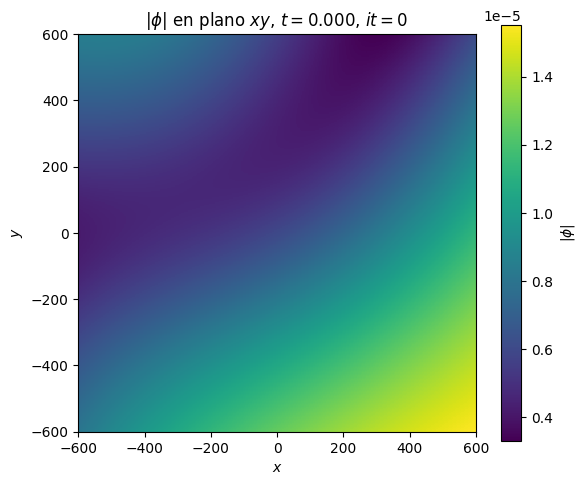

In [3]:
plot_phi_xy_fast(it=0, part="abs")

In [182]:
import h5py
import numpy as np
import matplotlib.pyplot as plt
from scipy.special import sph_harm
from matplotlib.patches import Circle
from matplotlib.colors import LogNorm, SymLogNorm

fname = "rand_01/modes.h5"

def lm_of_n(n):
    l = int(np.floor(np.sqrt(n)))
    m = n - l*l - l
    return l, m

# ------------------------------------------------------------
# Parámetros de la reconstrucción polar directa
# ------------------------------------------------------------

Rs = 1.0

# Radio interior a graficar.
# Usa Rs=1 para ocultar el interior del horizonte.
# Usa r_data.min() después de cargar si quieres mostrar hasta la excisión numérica.
r_inner_plot = Rs

# Radio exterior mostrado
Lbox = 600.0

# Resolución angular
Nphi = 320

# Si la figura pesa mucho, usa r_stride=2, 3, 4...
# r_stride=1 usa directamente todos los puntos radiales disponibles.
r_stride = 2

# ------------------------------------------------------------
# Cargar datos
# ------------------------------------------------------------

modes = []

with h5py.File(fname, "r") as f:
    groups = sorted(
        [g for g in f.keys() if g.startswith("mode_")],
        key=lambda s: int(s.split("_")[1])
    )

    g0 = groups[0]

    if "r" in f:
        r_data = f["r"][:].astype(np.float64)
    else:
        r_data = f[g0]["vr"][:, 0].astype(np.float64)

    t_data = f[g0]["t"][:]

    r_outer_plot = min(Lbox, r_data.max())

    idx_r = np.where((r_data >= r_inner_plot) & (r_data <= r_outer_plot))[0]
    idx_r = idx_r[::r_stride]

    rp = r_data[idx_r]

    phip = np.linspace(-np.pi, np.pi, Nphi, endpoint=True, dtype=np.float64)

    RR, PP = np.meshgrid(rp, phip, indexing="ij")
    XX = RR * np.cos(PP)
    YY = RR * np.sin(PP)

    for g in groups:
        n = int(g.split("_")[1])
        l, m = lm_of_n(n)

        # En theta = pi/2, Y_lm = 0 si l+m es impar
        if (l + m) % 2 != 0:
            continue

        # Parte angular completa en el plano xy:
        # theta = pi/2, phi = phip
        Y0 = sph_harm(m, l, 0.0, np.pi/2)
        Yphi = Y0 * np.exp(1j * m * phip)

        # phi tiene forma {2, Nr, Nt}
        # Guardamos únicamente el rango radial que vamos a graficar
        phi_all = f[g]["phi"][:, idx_r, :].astype(np.float32)

        modes.append((l, m, phi_all, Yphi.astype(np.complex64)))

print("Modos usados:", [(l, m) for l, m, _, _ in modes])
print("Nt =", len(t_data))
print("Nr original =", len(r_data))
print("Nr usado para graficar =", len(rp))
print("r_inner_plot =", r_inner_plot)
print("r_outer_plot =", r_outer_plot)
print("Nphi =", Nphi)

/tmp/ipykernel_19845/3960036337.py:80: DeprecationWarning: `scipy.special.sph_harm` is deprecated as of SciPy 1.15.0 and will be removed in SciPy 1.17.0. Please use `scipy.special.sph_harm_y` instead.
  Y0 = sph_harm(m, l, 0.0, np.pi/2)


Modos usados: [(0, 0), (1, -1), (1, 1), (2, -2), (2, 0), (2, 2), (3, -3), (3, -1), (3, 1), (3, 3), (4, -4), (4, -2), (4, 0), (4, 2), (4, 4), (5, -5), (5, -3), (5, -1), (5, 1), (5, 3), (5, 5), (6, -6), (6, -4), (6, -2), (6, 0), (6, 2), (6, 4), (6, 6), (7, -7), (7, -5), (7, -3), (7, -1), (7, 1), (7, 3), (7, 5), (7, 7), (8, -8), (8, -6), (8, -4), (8, -2), (8, 0), (8, 2), (8, 4), (8, 6), (8, 8), (9, -9), (9, -7), (9, -5), (9, -3), (9, -1), (9, 1), (9, 3), (9, 5), (9, 7), (9, 9), (10, -10), (10, -8), (10, -6), (10, -4), (10, -2), (10, 0), (10, 2), (10, 4), (10, 6), (10, 8), (10, 10), (11, -11), (11, -9), (11, -7), (11, -5), (11, -3), (11, -1), (11, 1), (11, 3), (11, 5), (11, 7), (11, 9), (11, 11), (12, -12), (12, -10), (12, -8), (12, -6), (12, -4), (12, -2), (12, 0), (12, 2), (12, 4), (12, 6), (12, 8), (12, 10), (12, 12), (13, -13), (13, -11), (13, -9), (13, -7), (13, -5), (13, -3), (13, -1), (13, 1), (13, 3), (13, 5), (13, 7), (13, 9), (13, 11), (13, 13), (14, -14), (14, -12), (14, -10), (

In [186]:
def reconstruct_phi_xy_polar_direct(it):
    """
    Reconstruye phi(t,x,y) usando directamente la malla radial rp,
    sin interpolación radial.

    Devuelve:
        field con shape (Nr_plot, Nphi)
    """
    field = np.zeros((len(rp), len(phip)), dtype=np.complex64)

    for l, m, phi_all, Yphi in modes:
        phi_lm_r = phi_all[0, :, it] + 1j * phi_all[1, :, it]

        field += phi_lm_r[:, None].astype(np.complex64) * Yphi[None, :]

    return field


def plot_phi_xy_polar_direct(
    it,
    part="abs",
    log_abs=False,
    sym_log=False,
    cmap_name="viridis",
    percentile_vmin=1.0,
    percentile_vmax=99.8,
    linthresh=1e-6,
    draw_outer_circle=True,
    draw_inner_circle=True
):
    """
    Grafica la reconstrucción polar directa en el plano xy.

    Parámetros
    ----------
    it : int
        Índice temporal.

    part : str
        "abs", "real" o "imag".

    log_abs : bool
        Si part="abs", usa escala logarítmica y evita que ceros numéricos
        contaminen la barra de color.

    sym_log : bool
        Si part="real" o part="imag", usa escala simétrica logarítmica.

    cmap_name : str
        Colormap.

    percentile_vmin, percentile_vmax : float
        Percentiles para fijar límites de color de forma robusta.

    linthresh : float
        Umbral lineal para SymLogNorm en partes real/imaginaria.
    """

    field = reconstruct_phi_xy_polar_direct(it)

    if part == "abs":
        Q = np.abs(field)
        label = r"$|\phi|$"
    elif part == "real":
        Q = field.real
        label = r"$\mathrm{Re}(\phi)$"
    elif part == "imag":
        Q = field.imag
        label = r"$\mathrm{Im}(\phi)$"
    else:
        raise ValueError("part debe ser 'abs', 'real' o 'imag'")

    cmap = plt.get_cmap(cmap_name).copy()
    cmap.set_bad("white")

    norm = None

    if part == "abs":
        if log_abs:
            positive = Q[np.isfinite(Q) & (Q > 0)]

            if len(positive) == 0:
                raise ValueError("No hay valores positivos para usar LogNorm.")

            vmin = np.percentile(positive, percentile_vmin)
            vmax = np.percentile(positive, percentile_vmax)

            Q = np.where(Q >= vmin, Q, np.nan)
            norm = LogNorm(vmin=vmin, vmax=vmax)

        else:
            finite = Q[np.isfinite(Q)]
            vmin = np.percentile(finite, percentile_vmin)
            vmax = np.percentile(finite, percentile_vmax)

    else:
        finite = Q[np.isfinite(Q)]

        if sym_log:
            vmax = np.percentile(np.abs(finite), percentile_vmax)
            vmin = -vmax
            norm = SymLogNorm(
                linthresh=linthresh,
                vmin=vmin,
                vmax=vmax
            )
        else:
            vmax = np.percentile(np.abs(finite), percentile_vmax)
            vmin = -vmax

    Qplot = np.ma.masked_invalid(Q)

    fig, ax = plt.subplots(figsize=(6.4, 5.6))

    if norm is None:
        im = ax.pcolormesh(
            XX,
            YY,
            Qplot,
            shading="auto",
            cmap=cmap,
            vmin=vmin,
            vmax=vmax
        )
    else:
        im = ax.pcolormesh(
            XX,
            YY,
            Qplot,
            shading="auto",
            cmap=cmap,
            norm=norm
        )

    ax.set_aspect("equal")
    ax.set_xlim(-r_outer_plot, r_outer_plot)
    ax.set_ylim(-r_outer_plot, r_outer_plot)

    if draw_outer_circle:
        ax.add_patch(
            Circle(
                (0.0, 0.0),
                r_outer_plot,
                fill=False,
                color="k",
                linewidth=1.2,
                zorder=5
            )
        )

    if draw_inner_circle:
        ax.add_patch(
            Circle(
                (0.0, 0.0),
                r_inner_plot,
                facecolor="black",
                edgecolor="black",
                linewidth=1.0,
                zorder=6
            )
        )

    ax.set_xlabel(r"$x$")
    ax.set_ylabel(r"$y$")
    ax.set_title(fr"{label} en plano $xy$, $t={t_data[it]:.3f}$")

    plt.colorbar(im, ax=ax, label=label)
    plt.tight_layout()
    plt.show()

/tmp/ipykernel_19845/2645486956.py:116: UserWarning: The input coordinates to pcolormesh are interpreted as cell centers, but are not monotonically increasing or decreasing. This may lead to incorrectly calculated cell edges, in which case, please supply explicit cell edges to pcolormesh.
  im = ax.pcolormesh(


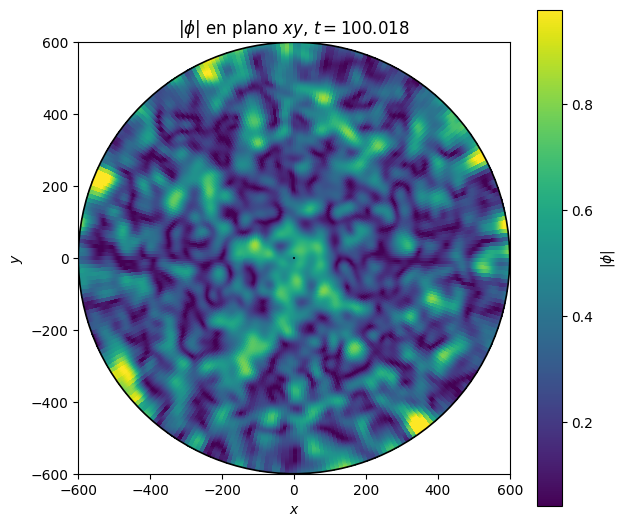

In [189]:
plot_phi_xy_polar_direct(it=10, part="abs", log_abs=False)

In [146]:
import h5py
import numpy as np
import matplotlib.pyplot as plt


def n_of_lm(ell, m):
    """
    Inversa de:
        ell = floor(sqrt(n))
        m = n - ell^2 - ell

    Entonces:
        n = ell^2 + ell + m
    """
    return ell*ell + ell + m


def find_group_for_lm(f, ell_target, m_target):
    """
    Busca el grupo mode_XXXXX correspondiente a un ell,m.
    """
    n_target = n_of_lm(ell_target, m_target)

    # Primero intenta con formato estándar
    candidates = [
        f"mode_{n_target:05d}",
        f"mode_{n_target:04d}",
        f"mode_{n_target}"
    ]

    for gname in candidates:
        if gname in f:
            return gname

    # Si no lo encuentra, busca recorriendo todos los grupos
    for gname in f.keys():
        if not gname.startswith("mode_"):
            continue

        n = int(gname.split("_")[1])
        ell, m = lm_of_n(n)

        if ell == ell_target and m == m_target:
            return gname

    raise KeyError(f"No encontré el modo ell={ell_target}, m={m_target}, n={n_target}")


def read_complex_mode_dataset(g, var):
    """
    Lee un dataset complejo guardado como:
        var shape = (2, Nr, Nt)
    o complejo nativo.
    """
    if var not in g:
        raise KeyError(f"No existe '{var}' en {g.name}. Datasets disponibles: {list(g.keys())}")

    A = g[var][:]

    if np.iscomplexobj(A):
        return A

    # Caso esperado en tu archivo: (2, Nr, Nt)
    if A.ndim == 3 and A.shape[0] == 2:
        return A[0, :, :] + 1j*A[1, :, :]

    # Caso alternativo: (Nr, Nt, 2)
    if A.ndim == 3 and A.shape[-1] == 2:
        return A[:, :, 0] + 1j*A[:, :, 1]

    raise ValueError(f"Formato inesperado para {g.name}/{var}: shape={A.shape}")


def plot_lm_1d(
    fname,
    ell,
    m,
    i=1,
    vars_to_plot=("phi", "psi", "pi"),
    rlim=(0.45, 5.0),
    logy=True,
    normalize=False,
    abs_only=True,
):
    """
    Grafica perfiles radiales 1D de un modo específico (ell,m).

    Parámetros:
        fname        : archivo HDF5
        ell, m       : modo deseado
        i            : índice temporal
        vars_to_plot : variables a graficar, por ejemplo ("phi", "psi", "pi")
        rlim         : límites radiales
        logy         : escala logarítmica para |campo|
        normalize    : normaliza cada perfil por su máximo
        abs_only     : si True grafica |campo|; si False grafica Re, Im y |campo|
    """

    with h5py.File(fname, "r") as f:

        gname = find_group_for_lm(f, ell, m)
        g = f[gname]

        if "r" in f:
            r = f["r"][:]
        elif "vr" in g:
            r = g["vr"][:, 0]
        else:
            raise KeyError("No encontré r en el archivo ni vr en el grupo.")

        if "t" in g:
            t = g["t"][:]
        elif "t" in f:
            t = f["t"][:]
        else:
            t = None

        if t is not None:
            time_label = fr"$t={t[i]:.6g}$"
        else:
            time_label = fr"$i={i}$"

        print(f"Graficando grupo: {gname}")
        print(f"Modo: ell={ell}, m={m}, n={n_of_lm(ell,m)}")
        print(f"Tiempo: {time_label}")

        for var in vars_to_plot:

            A = read_complex_mode_dataset(g, var)

            if A.ndim != 2:
                raise ValueError(f"Esperaba {var} con shape (Nr,Nt), llegó {A.shape}")

            if i >= A.shape[1]:
                raise IndexError(f"i={i} fuera de rango para {var}. Nt={A.shape[1]}")

            prof = A[:, i]
            amp = np.abs(prof)

            max_amp = np.nanmax(amp)
            idx_max = np.nanargmax(amp)
            r_max = r[idx_max]

            print(f"{var}: max |{var}| = {max_amp:.6e} en r = {r_max:.6e}")

            if abs_only:
                y = amp.copy()

                if normalize and max_amp > 0:
                    y = y / max_amp

                if logy:
                    y = np.maximum(y, 1e-300)

                plt.figure(figsize=(8, 4.5))
                plt.plot(r, y, lw=1.4)

                plt.axvline(1.0, color="k", ls="--", lw=1.0, label=r"$R_s$")
                plt.axvline(r[0], color="gray", ls=":", lw=1.0, label=r"$r_{\min}$")

                plt.xlim(*rlim)
                plt.xlabel(r"$r/R_s$")

                if normalize:
                    plt.ylabel(fr"$|{var}_{{\ell m}}|/\max |{var}_{{\ell m}}|$")
                else:
                    plt.ylabel(fr"$|{var}_{{\ell m}}|$")

                plt.title(fr"$|{var}_{{\ell m}}(r)|$, $\ell={ell}$, $m={m}$, {time_label}")

                if logy:
                    plt.yscale("log")

                plt.grid(alpha=0.25)
                plt.legend()
                plt.tight_layout()
                plt.show()

            else:
                plt.figure(figsize=(8, 4.5))

                plt.plot(r, np.real(prof), lw=1.2, label=fr"$\mathrm{{Re}}({var})$")
                plt.plot(r, np.imag(prof), lw=1.2, label=fr"$\mathrm{{Im}}({var})$")
                plt.plot(r, amp, lw=1.4, color="k", label=fr"$|{var}|$")

                plt.axvline(1.0, color="k", ls="--", lw=1.0, alpha=0.7)
                plt.axvline(r[0], color="gray", ls=":", lw=1.0)

                plt.xlim(*rlim)
                plt.xlabel(r"$r/R_s$")
                plt.ylabel(fr"${var}_{{\ell m}}$")
                plt.title(fr"${var}_{{\ell m}}(r)$, $\ell={ell}$, $m={m}$, {time_label}")

                plt.grid(alpha=0.25)
                plt.legend()
                plt.tight_layout()
                plt.show()

Graficando grupo: mode_02550
Modo: ell=50, m=0, n=2550
Tiempo: $t=30.0053$
phi: max |phi| = 6.739505e-03 en r = 6.004000e+02


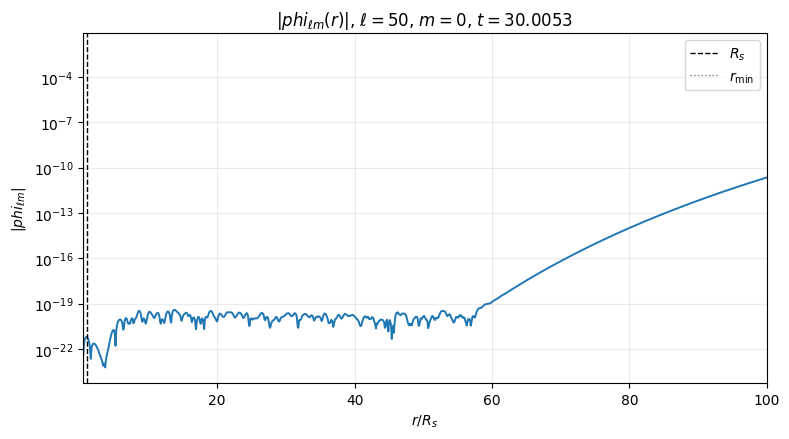

pi: max |pi| = 1.459827e-03 en r = 5.482913e+02


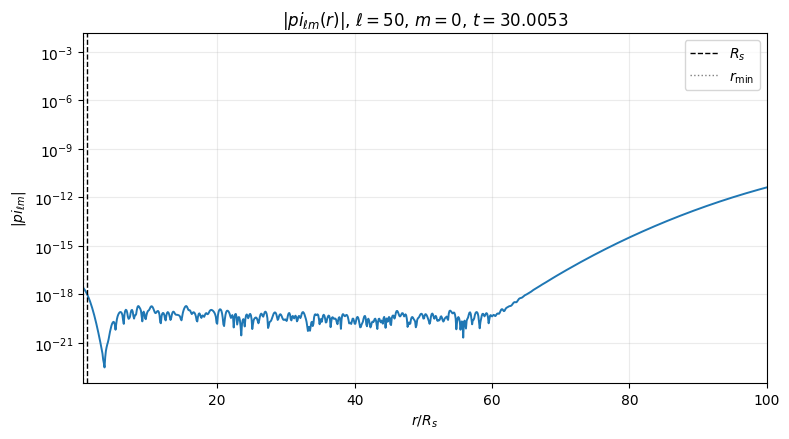

In [172]:
plot_lm_1d(
    fname,
    ell=50,
    m=0,
    i=3,
    vars_to_plot=("phi", "pi"),
    rlim=(0.45, 100.0),
    logy=True,
    normalize=False,
    abs_only=True
)